# Explainability, Fairness, and Drift in the IRIS Pipeline

## Week 9 MLOps Assignment

This notebook extends the IRIS classification pipeline with responsible
machine learning practices:

- Fairness evaluation using Fairlearn
- Model explainability using SHAP
- Data drift detection
- Model governance and documentation

The `location` attribute is introduced as a synthetic sensitive attribute.
It is used only for fairness analysis and is not used as a model feature.

In [1]:
pip install -U numpy pandas scikit-learn matplotlib seaborn scipy fairlearn shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from fairlearn.metrics import MetricFrame

import shap

from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("Environment ready.")

Environment ready.


In [3]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

feature_names = iris.feature_names
class_names = iris.target_names

print("Dataset shape:", X.shape)
print("Classes:", list(class_names))

display(X.head())

Dataset shape: (150, 4)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Baseline model

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


In [5]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Baseline Model Performance")
print("--------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Baseline Model Performance
--------------------------
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333


## Task 1: Introduce sensitive attribute - location

In [6]:
# Randomly assign each Iris sample to location group 0 or 1
location = np.random.randint(
    0,
    2,
    size=len(X)
)

# Create a copy for auditing
iris_with_location = X.copy()
iris_with_location["location"] = location
iris_with_location["target"] = y

print("Dataset shape:", iris_with_location.shape)

print("\nLocation values:")
print(sorted(iris_with_location["location"].unique()))

print("\nLocation distribution:")
print(
    iris_with_location["location"]
    .value_counts()
    .sort_index()
)

display(iris_with_location.head())

Dataset shape: (150, 6)

Location values:
[np.int64(0), np.int64(1)]

Location distribution:
location
0    68
1    82
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),location,target
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0


In [7]:
print("Training features:")
print(X.columns.tolist())

print("\nSensitive attribute:")
print("location")

Training features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Sensitive attribute:
location


In [10]:
# Create location values corresponding to the existing train/test split

_, _, _, _, loc_train, loc_test = train_test_split(
    X,
    y,
    location,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Test-set location distribution:")
print(
    pd.Series(loc_test)
    .value_counts()
    .sort_index()
)

Test-set location distribution:
0    14
1    16
Name: count, dtype: int64


## Task 2: Fairlearn

In [11]:


fairness_metrics = {
    "accuracy": accuracy_score,
    "precision": lambda y_true, y_pred: precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "recall": lambda y_true, y_pred: recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
}

metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=loc_test
)

print("Performance by Location Group")
display(metric_frame.by_group)

Performance by Location Group


,accuracy,precision,recall
sensitive_feature_0,,,
0,0.928571,0.942857,0.928571
1,0.937500,0.953125,0.937500


## Fairness Interpretation

Fairlearn's MetricFrame shows the model performance separately for the two
location groups.

Location 0 achieves an accuracy of 0.9286, precision of 0.9429, and recall
of 0.9286. Location 1 achieves an accuracy of 0.9375, precision of 0.9531,
and recall of 0.9375.

The differences between the groups are small: approximately 0.9 percentage
points for accuracy and recall, and approximately 1.0 percentage point for
precision.

Because location was randomly assigned and was not included as a training
feature, these small differences are consistent with normal sampling
variation rather than evidence of systematic discrimination.

This demonstrates why subgroup-level fairness evaluation is important even
when the overall model performance is high.

In [12]:
print("Model type:", type(model).__name__)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Model type: DecisionTreeClassifier
Training shape: (120, 4)
Test shape: (30, 4)


## Task 3: SHAP Explainability

In [15]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (150, 4, 3)


### Generate summary plots for all 3 classes

SHAP Summary Plot: setosa


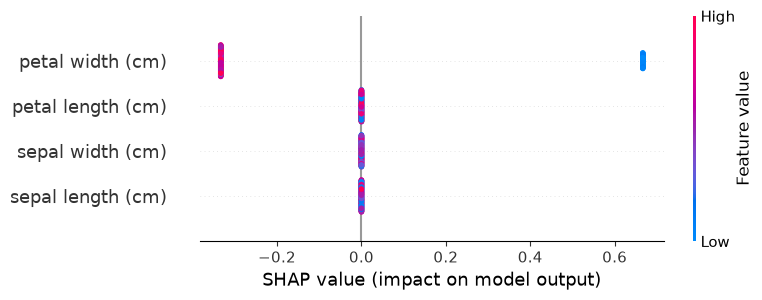

SHAP Summary Plot: versicolor


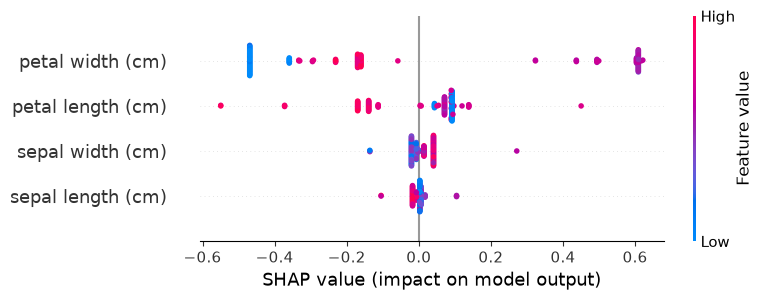

SHAP Summary Plot: virginica


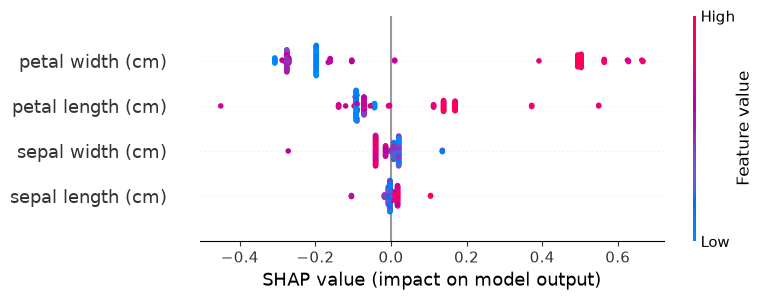

In [17]:
for class_index, class_name in enumerate(class_names):

    print(f"SHAP Summary Plot: {class_name}")

    class_shap_values = shap_values[:, :, class_index]

    shap.summary_plot(
        class_shap_values,
        X,
        feature_names=feature_names,
        show=True
    )

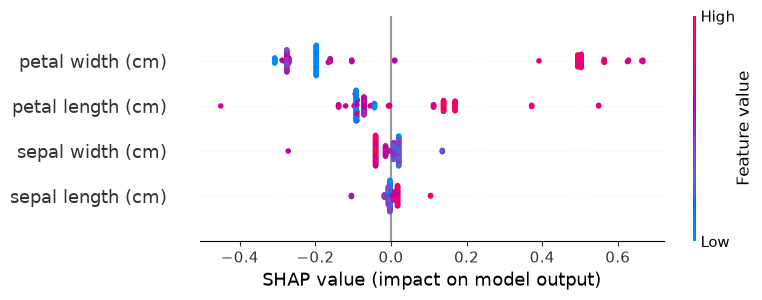

In [18]:
virginica_shap_values = shap_values[:, :, 2]

shap.summary_plot(
    virginica_shap_values,
    X,
    feature_names=feature_names,
    show=True
)

## Task 4: Data Drift Detection

In [19]:
reference_data = X_train.copy()

production_data = X_train.copy()

# Simulate production distribution changes
production_data["petal length (cm)"] += 0.8
production_data["petal width (cm)"] += 0.3

print("Reference data shape:", reference_data.shape)
print("Production data shape:", production_data.shape)

display(production_data.head())

Reference data shape: (120, 4)
Production data shape: (120, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
8,4.4,2.9,2.2,0.5
106,4.9,2.5,5.3,2.0
76,6.8,2.8,5.6,1.7
9,4.9,3.1,2.3,0.4
89,5.5,2.5,4.8,1.6


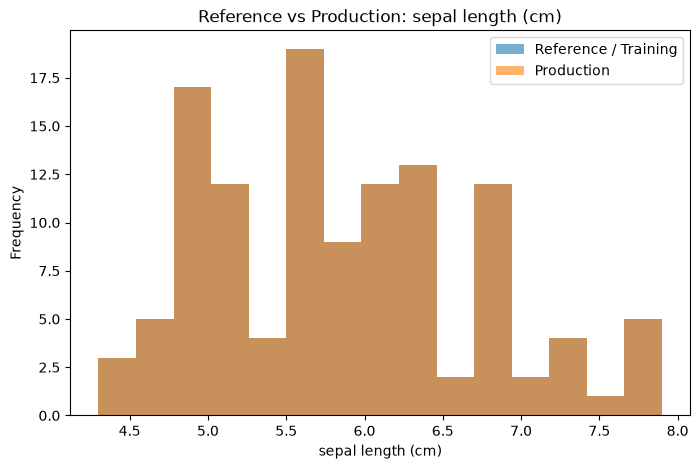

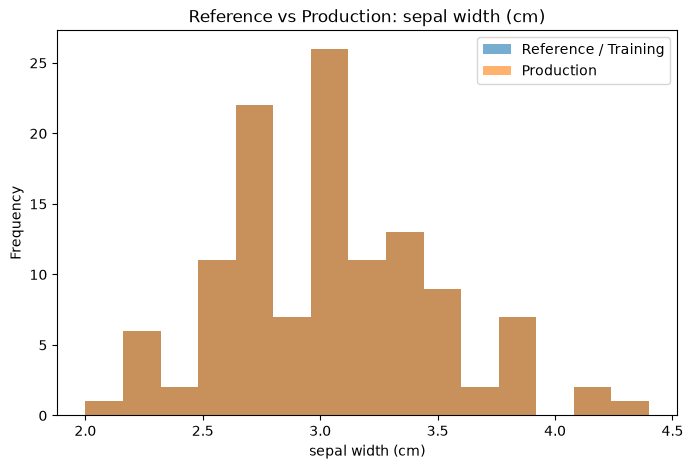

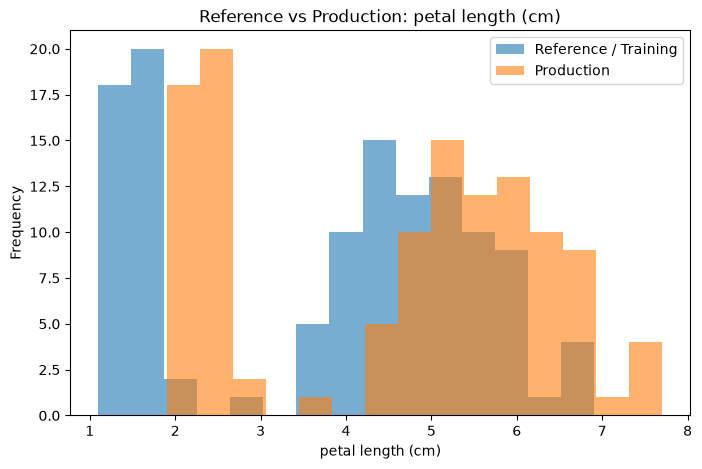

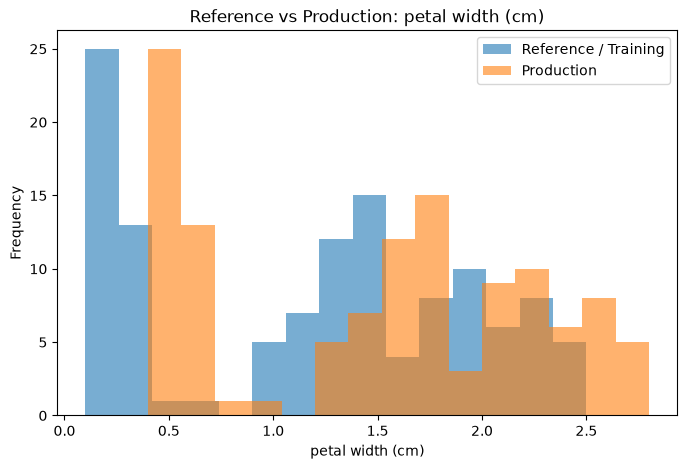

In [20]:
for feature in feature_names:

    plt.figure(figsize=(8, 5))

    plt.hist(
        reference_data[feature],
        bins=15,
        alpha=0.6,
        label="Reference / Training"
    )

    plt.hist(
        production_data[feature],
        bins=15,
        alpha=0.6,
        label="Production"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Reference vs Production: {feature}")
    plt.legend()
    plt.show()

In [21]:
drift_results = []

for feature in feature_names:

    statistic, p_value = ks_2samp(
        reference_data[feature],
        production_data[feature]
    )

    drift_results.append({
        "Feature": feature,
        "KS Statistic": statistic,
        "p-value": p_value,
        "Drift Detected": p_value < 0.05
    })

drift_df = pd.DataFrame(drift_results)

display(drift_df)

,Feature,KS Statistic,p-value,Drift Detected
0,sepal length (cm),0.000000,1.000000,False
1,sepal width (cm),0.000000,1.000000,False
2,petal length (cm),0.333333,0.000003,True
3,petal width (cm),0.275000,0.000212,True


In [22]:
print("========== Data Drift Analysis ==========")

for _, row in drift_df.iterrows():

    if row["Drift Detected"]:
        print(
            f"{row['Feature']}: DRIFT DETECTED "
            f"(p-value = {row['p-value']:.6f})"
        )
    else:
        print(
            f"{row['Feature']}: No significant drift "
            f"(p-value = {row['p-value']:.6f})"
        )

========== Data Drift Analysis ==========
sepal length (cm): No significant drift (p-value = 1.000000)
sepal width (cm): No significant drift (p-value = 1.000000)
petal length (cm): DRIFT DETECTED (p-value = 0.000003)
petal width (cm): DRIFT DETECTED (p-value = 0.000212)


## Drift Interpretation

The simulated production dataset was created by shifting the distributions of
petal length and petal width in the reference training data.

The Kolmogorov-Smirnov (KS) test was used to compare each feature between the
reference and production datasets. A p-value below 0.05 was considered
evidence of statistically significant distribution drift.

The results show no significant drift for sepal length or sepal width.
However, significant drift was detected for petal length (p = 0.000003) and
petal width (p = 0.000212).

This means that the production input distribution is different from the
distribution on which the model was trained for these two features. In a
real production system, this could indicate that the model is receiving data
different from its training environment and may eventually experience
reduced prediction reliability.

This experiment demonstrates data drift rather than concept drift. We
changed the distribution of the input features but did not change the
underlying relationship between the features and the target.

# Model Card — IRIS Classifier

## Model Details

**Model:** Decision Tree Classifier

**Task:** Multi-class classification of Iris flowers.

**Classes:** Setosa, Versicolor, Virginica

**Features used for training:**
- Sepal length
- Sepal width
- Petal length
- Petal width

The synthetic `location` attribute was not used as a training feature. It was
used exclusively as a sensitive attribute for fairness evaluation.

## Intended Use

This model is intended for educational demonstration of responsible machine
learning practices, including fairness auditing, model explainability, and
data-drift monitoring.

It is not intended for safety-critical or high-stakes decision-making.

## Training Data

The model uses the Iris dataset provided by
`sklearn.datasets.load_iris()`.

The dataset contains 150 observations, four numerical features, and three
target classes.

## Overall Performance

| Metric | Score |
|---|---:|
| Accuracy | 0.9333 |
| Precision | 0.9333 |
| Recall | 0.9333 |
| F1 Score | 0.9333 |

## Fairness Evaluation

A randomly assigned binary `location` attribute was introduced as a
sensitive attribute.

| Location | Accuracy | Precision | Recall |
|---|---:|---:|---:|
| 0 | 0.9286 | 0.9429 | 0.9286 |
| 1 | 0.9375 | 0.9531 | 0.9375 |

The differences between the groups are small. Since location was randomly
assigned and excluded from training, these differences should not be
interpreted as evidence of systematic discrimination.

## Explainability

SHAP was used to explain the Decision Tree classifier.

SHAP summary plots were generated for all three Iris classes. The Virginica
class was examined in detail.

Positive SHAP values indicate that a feature contributes toward the selected
class, while negative SHAP values indicate a contribution away from that
class.

Red points represent high feature values and blue points represent low
feature values.

## Drift Monitoring

A simulated production dataset was generated by shifting petal length and
petal width.

The KS test detected significant drift in:

- Petal length — p = 0.000003
- Petal width — p = 0.000212

No significant drift was detected in:

- Sepal length — p = 1.000000
- Sepal width — p = 1.000000

In production, such drift should trigger further investigation and
monitoring of model performance.

## Limitations

- The Iris dataset is small and relatively simple.
- The location attribute is synthetic and randomly generated.
- The fairness evaluation therefore does not represent a real demographic
  population.
- The test set is small, so subgroup metrics can vary due to sampling.
- The production drift is artificially simulated.
- SHAP explains model behavior but does not establish causal relationships.
- The model is intended for educational use and not high-stakes decisions.

## Governance Considerations

A production deployment should maintain:

- Training-data documentation
- Model versioning
- Fairness monitoring
- Feature-drift monitoring
- Prediction-performance monitoring
- Model limitations and intended-use documentation
- Periodic model review